# Titanic Survival — Exploratory Data Analysis
Goal: understand structure, data quality, and what drives survival, so every
preprocessing choice in the next stage is justified by something seen here.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.size": 11, "axes.titlesize": 13, "axes.titleweight": "bold",
    "axes.labelcolor": "#264653", "text.color": "#264653",
    "xtick.color": "#8A98A5", "ytick.color": "#8A98A5", "axes.edgecolor": "#D6DCE2",
})

# Kaggle auth comes from the environment / ~/.kaggle (no secret hardcoded here).
path = kagglehub.competition_download("titanic")
print("Path to competition files:", path)

df = pd.read_csv(f"{path}/train.csv")
print(df.shape)   # (891, 12)
df.head()

Path to competition files: /Users/ilyayaverbaum/.cache/kagglehub/competitions/titanic
(891, 12)


/Users/ilyayaverbaum/PycharmProjects/home_assignment_ilya_yaverbaum/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
# ---- shared palette + a reusable "survival rate by X" bar chart ----
DIED, SURVIVED, NAVY, MUTED, GRID = "#E76F51", "#2A9D8F", "#264653", "#8A98A5", "#ECECEC"
PALETTE = {0: DIED, 1: SURVIVED}

def pretty_rate_bar(col, title=None, order=None, rotate=0):
    """Polished survival-rate bar chart for any categorical column."""
    rates  = df.groupby(col, observed=True)["Survived"].mean()
    counts = df.groupby(col, observed=True)["Survived"].count()
    if order is None:
        order = rates.sort_values().index.tolist()          # low -> high reads naturally
    rates, counts = rates.reindex(order), counts.reindex(order)
    overall = df["Survived"].mean()
    colors = plt.cm.YlGnBu(plt.Normalize(0, 1)(rates.values) * 0.6 + 0.28)

    fig, ax = plt.subplots(figsize=(7.5, 5))
    ax.bar(range(len(rates)), rates.values, color=colors, edgecolor="white",
           lw=2, width=0.68, zorder=3)
    for i, (v, n) in enumerate(zip(rates.values, counts.values)):
        ax.annotate(f"{v:.0%}", (i, v), ha="center", va="bottom", fontsize=13,
                    fontweight="bold", color=NAVY, xytext=(0, 5), textcoords="offset points")
        ax.annotate(f"n={n}", (i, 0), ha="center", va="bottom", fontsize=8,
                    color="white", xytext=(0, 5), textcoords="offset points")
    ax.axhline(overall, color=DIED, ls="--", lw=1.6, zorder=2)
    ax.text(0, overall + 0.015, f"overall {overall:.0%}", color=DIED, fontsize=9, ha="left", va="bottom")
    ax.set_title(title or f"Survival rate by {col}", fontsize=14, fontweight="bold", loc="left", pad=12, color=NAVY)
    ax.set_xticks(range(len(rates))); ax.set_xticklabels(rates.index, fontsize=12, rotation=rotate)
    ax.set_ylabel("Survival rate"); ax.set_ylim(0, 1.0)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    ax.spines[["top", "right", "left"]].set_visible(False); ax.tick_params(left=False)
    ax.yaxis.grid(True, color=GRID); ax.set_axisbelow(True)
    plt.tight_layout(); plt.show()

We load only `train.csv` (the labelled file). Kaggle's `test.csv` has no
`Survived` column — it's the competition holdout — so it can't be used for
metric evaluation. We'll carve our own stratified held-out test set out of
these 891 rows later.

In [3]:
df.info()
df.describe(include="all").T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Braund, Mr. Owen Harris",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


In [4]:
missing_counts = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_data = pd.DataFrame({"Missing Values": missing_counts,
                             "Percentage (%)": missing_pct})
print(missing_data[missing_data["Missing Values"] > 0]
      .sort_values("Percentage (%)", ascending=False))

          Missing Values  Percentage (%)
Cabin                687       77.104377
Age                  177       19.865320
Embarked               2        0.224467


**Missingness:** Cabin 77.1%, Age 19.9%, Embarked 0.2% (2 rows).
- Cabin is too sparse to impute honestly → drop it, but first extract a
  coarse `HasCabin` flag (having a recorded cabin correlates with class).
- Age (20%) is worth imputing smartly — by passenger Title (see below).
- Embarked (2 rows) → fill with the mode (`S`).

In [5]:
print(f"Exact duplicate rows: {df.duplicated().sum()}")
print(f"Duplicate tickets:    {df['Ticket'].duplicated().sum()}")

print("\nPassengers sharing a ticket (families/groups):")
same_ticket = df[df["Ticket"].duplicated(keep=False)].sort_values("Ticket")
print(same_ticket[["Name", "Ticket", "Survived"]].head())

Exact duplicate rows: 0
Duplicate tickets:    210

Passengers sharing a ticket (families/groups):
                                                  Name  Ticket  Survived
257                               Cherry, Miss. Gladys  110152         1
759  Rothes, the Countess. of (Lucy Noel Martha Dye...  110152         1
504                              Maioni, Miss. Roberta  110152         1
262                                  Taussig, Mr. Emil  110413         0
558             Taussig, Mrs. Emil (Tillie Mandelbaum)  110413         1


In [6]:
# Look for impossible values (negative ages, etc.) and extreme maxima.
print(df[["Age", "Fare", "SibSp", "Parch"]].describe())

              Age        Fare       SibSp       Parch
count  714.000000  891.000000  891.000000  891.000000
mean    29.699118   32.204208    0.523008    0.381594
std     14.526497   49.693429    1.102743    0.806057
min      0.420000    0.000000    0.000000    0.000000
25%     20.125000    7.910400    0.000000    0.000000
50%     28.000000   14.454200    0.000000    0.000000
75%     38.000000   31.000000    1.000000    0.000000
max     80.000000  512.329200    8.000000    6.000000


In [7]:
for col in ["Pclass", "Sex", "Embarked"]:
    print(f"{col}: {df[col].unique()}")

Pclass: [3 1 2]
Sex: ['male' 'female']
Embarked: ['S' 'C' 'Q' nan]


          Count  Percentage (%)
Survived                       
0           549       61.616162
1           342       38.383838


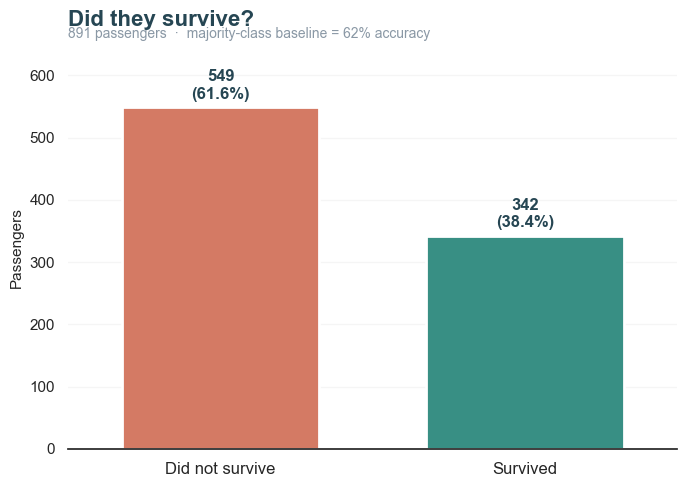

In [8]:
survival_counts = df["Survived"].value_counts()
survival_rates = df["Survived"].value_counts(normalize=True) * 100
print(pd.DataFrame({"Count": survival_counts, "Percentage (%)": survival_rates}))

with sns.axes_style("white"):
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.countplot(x="Survived", data=df, hue="Survived", palette=PALETTE,
                  legend=False, edgecolor="white", linewidth=2, width=0.65, ax=ax)
    total = len(df)
    for p in ax.patches:
        h = p.get_height()
        ax.annotate(f"{int(h)}\n({h/total:.1%})", (p.get_x() + p.get_width()/2, h),
                    ha="center", va="bottom", fontsize=12, fontweight="bold",
                    color=NAVY, xytext=(0, 4), textcoords="offset points")
    baseline = df["Survived"].value_counts(normalize=True).max()
    ax.set_title("Did they survive?", fontsize=16, fontweight="bold", pad=14, loc="left", color=NAVY)
    ax.text(0, 1.02, f"{total} passengers  ·  majority-class baseline = {baseline:.0%} accuracy",
            transform=ax.transAxes, fontsize=10, color=MUTED)
    ax.set_xlabel(""); ax.set_ylabel("Passengers", fontsize=11)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Did not survive", "Survived"], fontsize=12)
    ax.set_ylim(0, survival_counts.max() * 1.18)
    sns.despine(left=True); ax.tick_params(left=False)
    ax.yaxis.grid(True, color=GRID); ax.set_axisbelow(True)
    plt.tight_layout(); plt.show()

**Target:** 61.6% died, 38.4% survived — mildly imbalanced.
The **majority-class baseline ≈ 62% accuracy** (predict everyone dies); the
model must beat that to be useful. This is also why we'll report
**F1 and ROC-AUC**, not accuracy alone — accuracy of 62% can look "okay"
while the model learns nothing. We'll also **stratify** the train/val/test
split on `Survived`.

In [9]:
# Extract the honorific (Mr, Mrs, Miss, Master, ...) from Name.
df["Title"] = df["Name"].str.extract(r" ([A-Za-z]+)\.", expand=False)   # raw string

print("Missing ages, grouped by Title (what we're about to fill):")
print(df[df["Age"].isnull()]["Title"].value_counts())

Missing ages, grouped by Title (what we're about to fill):
Title
Mr        119
Miss       36
Mrs        17
Master      4
Dr          1
Name: count, dtype: int64


In [10]:
# Age: fill by Title-group median, with a global median safety-net in case a
# rare single-member title has no age at all.
df["Age"] = (df.groupby("Title")["Age"]
               .transform(lambda x: x.fillna(x.median()))
               .fillna(df["Age"].median()))

df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df["Fare"]     = df["Fare"].fillna(df["Fare"].median())

print("Remaining missing — Age:", df["Age"].isnull().sum(),
      "Embarked:", df["Embarked"].isnull().sum(),
      "Fare:", df["Fare"].isnull().sum())

print("\nMedian age by Title (why this beats a global median):")
print(df.groupby("Title")["Age"].median().sort_values().round(1))

Remaining missing — Age: 0 Embarked: 0 Fare: 0

Median age by Title (why this beats a global median):
Title
Master       3.5
Miss        21.0
Mlle        24.0
Mme         24.0
Ms          28.0
Mr          30.0
Countess    33.0
Mrs         35.0
Jonkheer    38.0
Don         40.0
Dr          46.5
Rev         46.5
Lady        48.0
Major       48.5
Sir         49.0
Col         58.0
Capt        70.0
Name: Age, dtype: float64


In [11]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"]    = (df["FamilySize"] == 1).astype(int)
df["FamilyBin"]  = pd.cut(df["FamilySize"], [0, 1, 4, 100],
                          labels=["Alone", "Small", "Large"])
df["HasCabin"]   = df["Cabin"].notna().astype(int)

# Collapse rare titles into 4 main groups + "Rare"
df["TitleGrp"] = df["Title"].replace(["Mlle", "Ms"], "Miss").replace("Mme", "Mrs")
df["TitleGrp"] = df["TitleGrp"].where(
    df["TitleGrp"].isin(["Mr", "Mrs", "Miss", "Master"]), "Rare")

df[["FamilySize", "IsAlone", "FamilyBin", "HasCabin", "TitleGrp"]].head()

,FamilySize,IsAlone,FamilyBin,HasCabin,TitleGrp
0,2,0,Small,0,Mr
1,2,0,Small,1,Mrs
2,1,1,Alone,0,Miss
3,2,0,Small,1,Mrs
4,1,1,Alone,0,Mr


In [12]:
print(df.groupby("HasCabin")["Survived"].agg(["mean","count"]).round(3))

           mean  count
HasCabin              
0         0.300    687
1         0.667    204


         mean  count
Sex                 
female  0.742    314
male    0.189    577


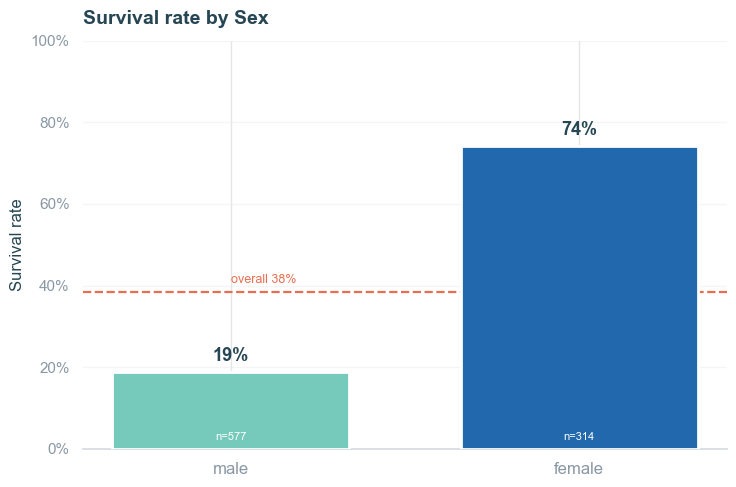

In [13]:
print(df.groupby("Sex")["Survived"].agg(["mean", "count"]).round(3))
pretty_rate_bar("Sex")

         mean  count
Pclass              
1       0.630    216
2       0.473    184
3       0.242    491


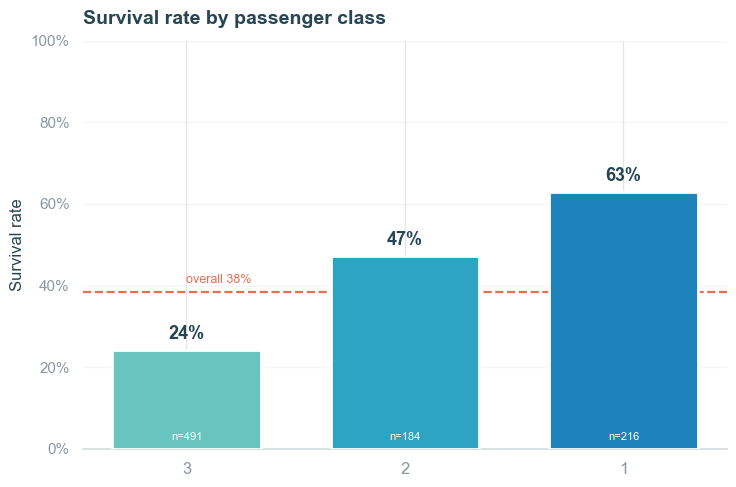

In [14]:
print(df.groupby("Pclass")["Survived"].agg(["mean", "count"]).round(3))
pretty_rate_bar("Pclass", title="Survival rate by passenger class")

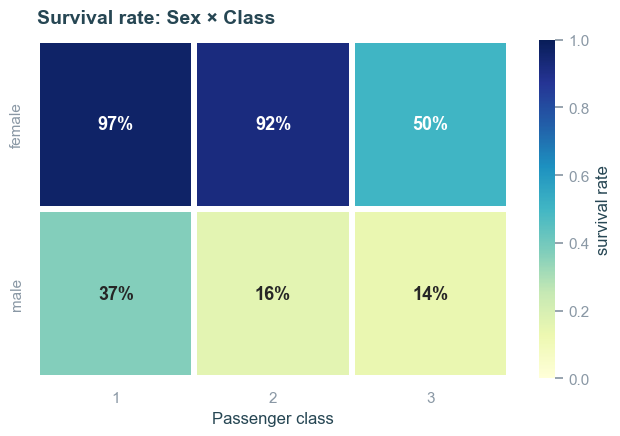

In [15]:
pivot = df.pivot_table("Survived", "Sex", "Pclass", "mean")
fig, ax = plt.subplots(figsize=(6.5, 4.5))
sns.heatmap(pivot, annot=True, fmt=".0%", cmap="YlGnBu", vmin=0, vmax=1,
            linewidths=3, linecolor="white", cbar_kws={"label": "survival rate"},
            annot_kws={"fontsize": 13, "fontweight": "bold"}, ax=ax)
ax.set_title("Survival rate: Sex × Class", fontsize=14, fontweight="bold", loc="left", color=NAVY, pad=12)
ax.set_xlabel("Passenger class"); ax.set_ylabel("")
plt.tight_layout(); plt.show()

**Sex is the strongest single predictor** (female 0.74 vs male 0.19), and
**class is a clean gradient** (1st 0.63 → 3rd 0.24). The heatmap shows they
**interact**: a 3rd-class woman (0.50) still out-survives a 1st-class man
(0.37). This non-additive interaction is exactly why a non-linear model can beat plain logistic regression here.

           mean  count
TitleGrp              
Master    0.575     40
Miss      0.703    185
Mr        0.157    517
Mrs       0.794    126
Rare      0.348     23


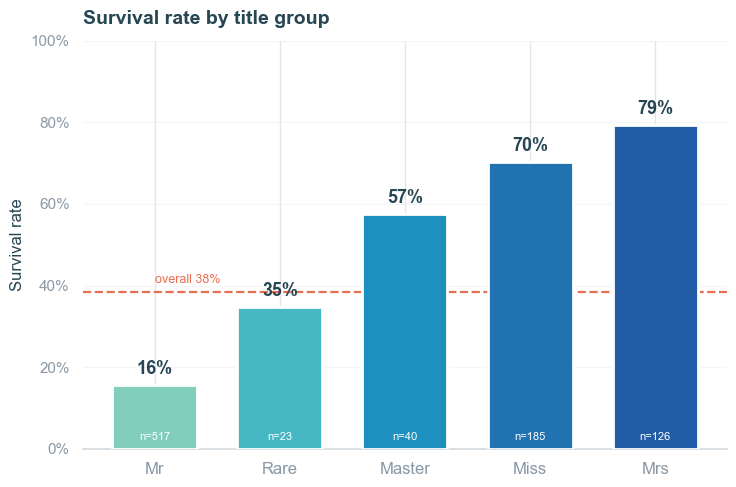

In [16]:
order = df.groupby("TitleGrp")["Survived"].mean().sort_values().index
print(df.groupby("TitleGrp")["Survived"].agg(["mean", "count"]).round(3))
pretty_rate_bar("TitleGrp", title="Survival rate by title group")

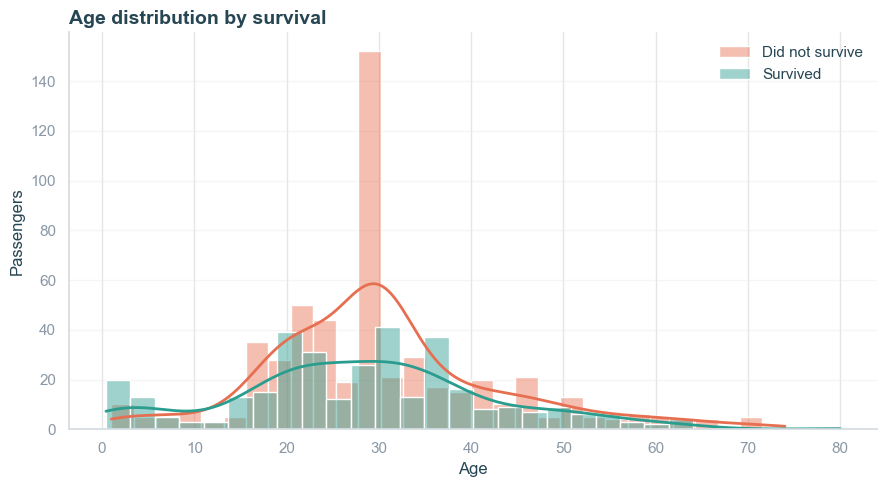

In [17]:
# Age distribution by survival  (note: ages were median-imputed above)
fig, ax = plt.subplots(figsize=(9, 5))
for val, color, lab in [(0, DIED, "Did not survive"), (1, SURVIVED, "Survived")]:
    sns.histplot(df[df["Survived"] == val]["Age"], bins=30, color=color, alpha=0.45,
                 label=lab, ax=ax, edgecolor="white", kde=True, line_kws={"lw": 2})
ax.set_title("Age distribution by survival", fontsize=14, fontweight="bold", loc="left", color=NAVY)
ax.legend(frameon=False); ax.set_xlabel("Age"); ax.set_ylabel("Passengers")
ax.spines[["top", "right"]].set_visible(False); ax.grid(axis="y", color=GRID); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

             mean  count
AgeBand                 
Child       0.575     73
Teen        0.429     70
YoungAdult  0.353    530
Adult       0.398    196
Senior      0.227     22


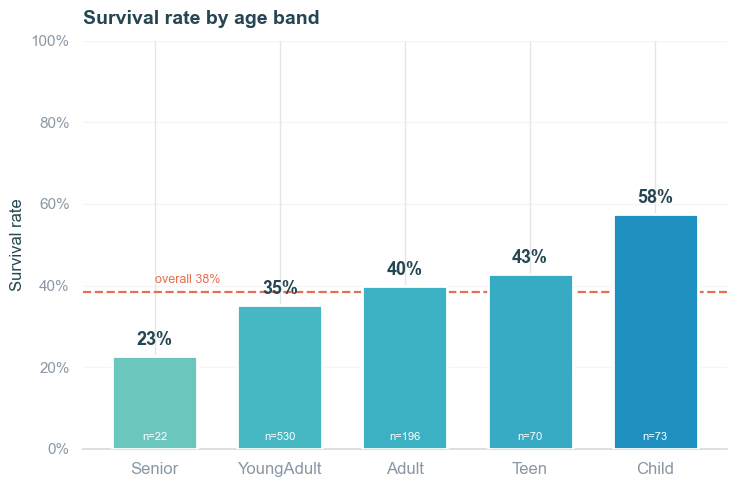

In [18]:
df["AgeBand"] = pd.cut(df["Age"], [0, 12, 18, 35, 60, 100],
                       labels=["Child", "Teen", "YoungAdult", "Adult", "Senior"])
print(df.groupby("AgeBand", observed=True)["Survived"].agg(["mean", "count"]).round(3))
pretty_rate_bar("AgeBand", title="Survival rate by age band")

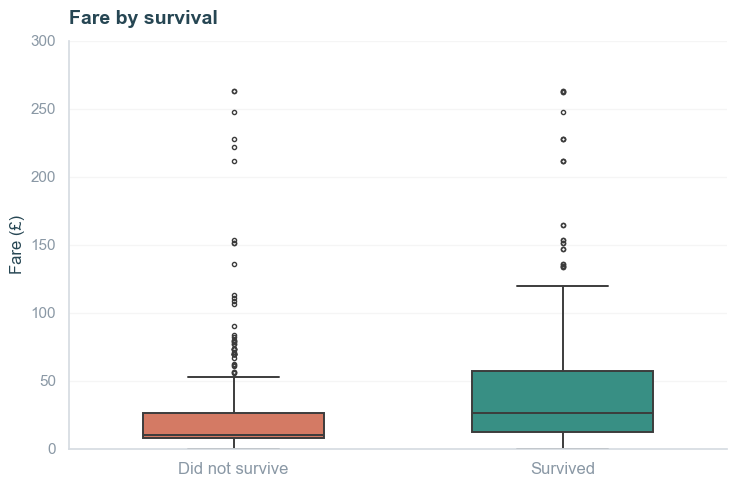

          mean  median
Survived              
0         22.1    10.5
1         48.4    26.0


In [19]:
fig, ax = plt.subplots(figsize=(7.5, 5))
sns.boxplot(x="Survived", y="Fare", data=df, hue="Survived", palette=PALETTE,
            legend=False, width=0.55, fliersize=3, linewidth=1.4, ax=ax)
ax.set_ylim(0, 300)
ax.set_title("Fare by survival", fontsize=14, fontweight="bold", loc="left", color=NAVY, pad=12)
ax.set_xticks([0, 1]); ax.set_xticklabels(["Did not survive", "Survived"], fontsize=12)
ax.set_xlabel(""); ax.set_ylabel("Fare (£)")
ax.spines[["top", "right"]].set_visible(False); ax.grid(axis="y", color=GRID); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()
print(df.groupby("Survived")["Fare"].agg(["mean", "median"]).round(1))

FamilySize
1     0.304
2     0.553
3     0.578
4     0.724
5     0.200
6     0.136
7     0.333
8     0.000
11    0.000
Name: Survived, dtype: float64


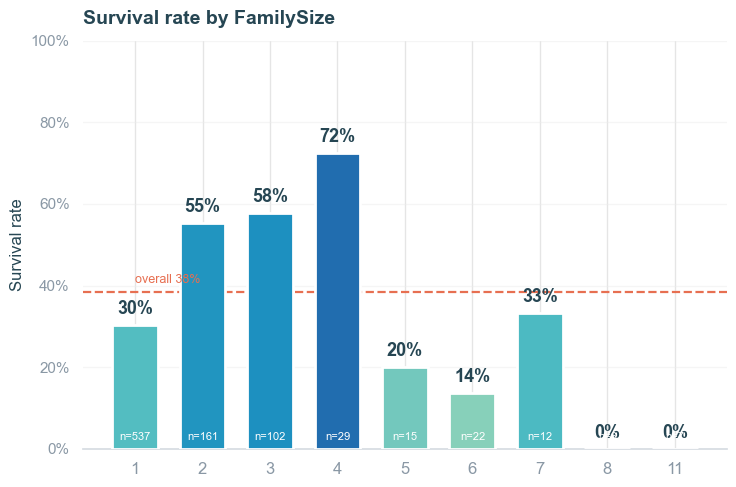

In [20]:
print(df.groupby("FamilySize")["Survived"].mean().round(3))
pretty_rate_bar("FamilySize", order=sorted(df["FamilySize"].unique()))

- **Title** packs sex + age + status into one feature: Mrs 0.79, Miss 0.70,
  Master 0.58, Mr 0.16 — highly predictive, keep it.
- **Fare** is right-skewed with extreme outliers (max 512); survivors paid
  more (median 26 vs 10.5). Real signal, but **log/robust-scale it** so the
  tail doesn't dominate.
- **FamilySize is non-monotonic:** solo 0.30 → peaks at size 4 (0.72) →
  collapses for large families (5+: ~0.16, sizes 8 & 11: 0.00). So don't feed
  raw FamilySize as one linear term — the `FamilyBin` (Alone/Small/Large) and
  `IsAlone` features capture the real shape.

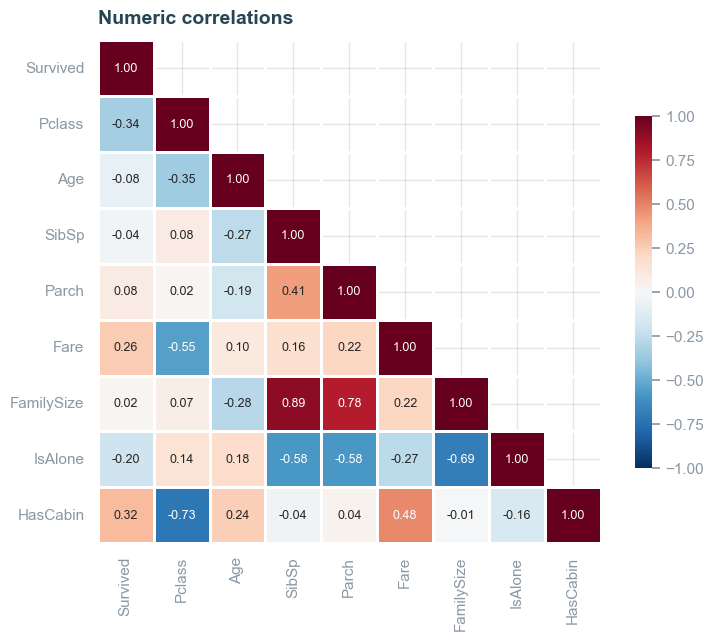

Pclass       -0.338
IsAlone      -0.203
Age          -0.079
SibSp        -0.035
FamilySize    0.017
Parch         0.082
Fare          0.257
HasCabin      0.317
Survived      1.000
Name: Survived, dtype: float64


In [21]:
num = df[["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare", "FamilySize", "IsAlone", "HasCabin"]]
corr = num.corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            linewidths=1, linecolor="white", square=True, cbar_kws={"shrink": 0.7},
            annot_kws={"fontsize": 9}, ax=ax)
ax.set_title("Numeric correlations", fontsize=14, fontweight="bold", loc="left", color=NAVY, pad=12)
plt.tight_layout(); plt.show()
print(num.corr()["Survived"].round(3).sort_values())

## EDA summary → preprocessing plan
**Top numeric drivers:** Pclass (−0.34), Fare (+0.26), IsAlone (−0.20).
Linear correlation *understates* Age and family because their effects are
non-linear (seen in the plots, not the corr table).

**Plan for `preprocess.py` (all fit on the training split only):**
- **Drop:** PassengerId, Name (after Title), Ticket, Cabin (keep `HasCabin`).
- **Impute:** Age → Title-group median; Embarked → mode; Fare → median.
- **Engineer:** Title (grouped), FamilySize, IsAlone, FamilyBin, HasCabin.
- **Transform:** log/robust-scale Fare; standard-scale numerics; one-hot
  encode Sex, Embarked, Title, FamilyBin.
- **Split:** stratified train/val/test on Survived.
- **Metrics:** ROC-AUC + F1 primary; accuracy vs the 62% baseline secondary.